# 🧠 ML Pipeline for Project Management System

> **Training Notebook** — Task Classification, Priority Classification, Duration Prediction
>
> Dataset: Synthetic JIRA Issues (3000 records)
>
> Models: TF-IDF + Logistic Regression, Random Forest, Gradient Boosting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("All imports successful ✅")

All imports successful ✅


## 📁 1. Load Dataset

In [2]:
df = pd.read_csv('data/jira_issues_dataset.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (3000, 12)


,issue_id,title,description,issue_type,priority,status,story_points,duration_days,created_date,due_date,assignee,project
0,PROJ-1000,Handle edge case in user validation,Users are experiencing UI freeze when trying t...,Bug,Highest,Done,1,14,2024-01-17,2024-01-31,user_3,Project-Delta
1,PROJ-1001,Implement lazy loading for file upload,Build sprint planning with proper error bounda...,Frontend,Medium,To Do,6,30,2024-01-04,2024-02-03,user_14,Project-Zeta
2,PROJ-1002,Create backup strategy for task database,DevOps task: Set up infrastructure for permiss...,Devops,High,Done,6,20,2024-01-23,2024-02-12,user_18,Project-Beta
3,PROJ-1003,Update kanban error messages,Technical debt item: dashboard needs saving da...,Task,High,In Review,2,13,2024-02-10,2024-02-23,user_4,Project-Eta
4,PROJ-1004,Add comments search and filter,We need to implement calendar in the inventory...,Feature,Low,In Progress,11,56,2024-09-30,2024-11-25,user_6,Project-Theta


## 🔍 2. Data Inspection & Cleaning

In [3]:
print("=== Info ===")
print(df.dtypes)
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")

=== Info ===
issue_id         object
title            object
description      object
issue_type       object
priority         object
status           object
story_points      int64
duration_days     int64
created_date     object
due_date         object
assignee         object
project          object
dtype: object

Null counts:
issue_id         0
title            0
description      0
issue_type       0
priority         0
status           0
story_points     0
duration_days    0
created_date     0
due_date         0
assignee         0
project          0
dtype: int64

Duplicates: 0


In [4]:
# Drop duplicates and nulls
df = df.drop_duplicates()
df = df.dropna(subset=['title', 'description', 'issue_type', 'priority', 'duration_days'])

# Combine text features
df['text'] = df['title'] + ' ' + df['description']
df['text'] = df['text'].str.lower().str.replace(r'[^a-z0-9\s]', '', regex=True).str.strip()

# Verify categories match the app
print("Issue Types:", df['issue_type'].unique())
print("Priorities:", df['priority'].unique())
print(f"\nCleaned shape: {df.shape}")

Issue Types: ['Bug' 'Frontend' 'Devops' 'Task' 'Feature' 'Docs' 'Backend' 'Design']
Priorities: ['Highest' 'Medium' 'High' 'Low']

Cleaned shape: (3000, 13)


## 📊 3. Exploratory Data Analysis (EDA)

### 3.1 Category Distribution

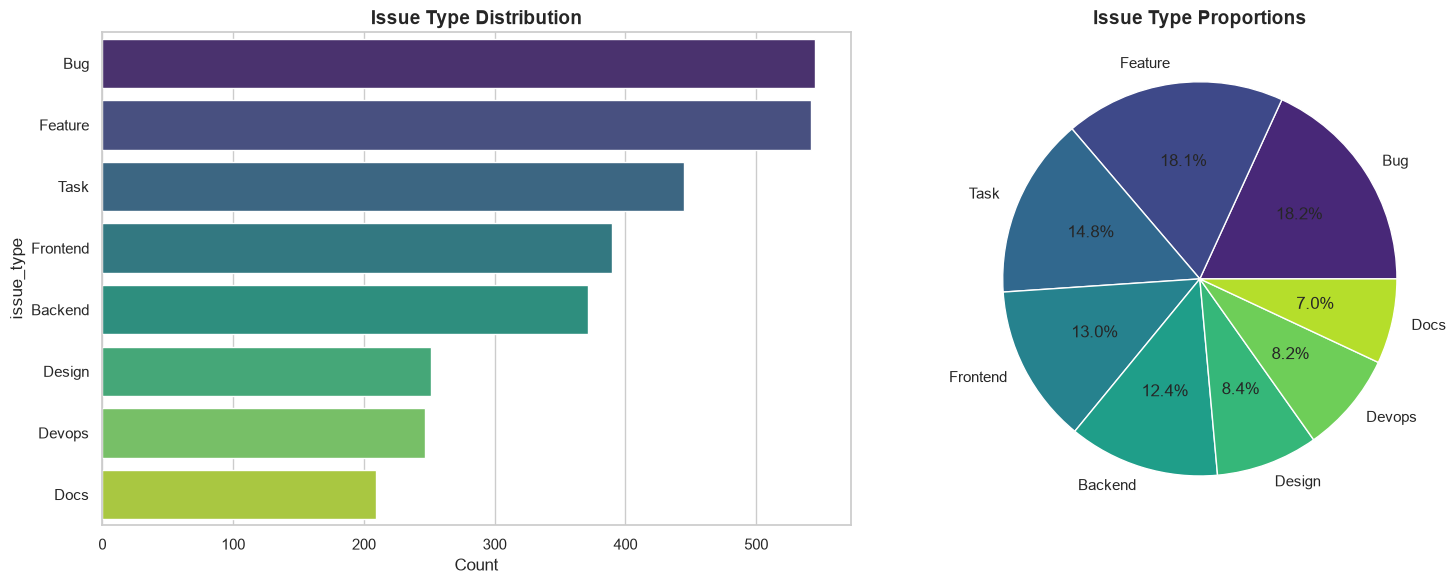

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
order = df['issue_type'].value_counts().index
sns.countplot(data=df, y='issue_type', order=order, ax=axes[0], palette='viridis')
axes[0].set_title('Issue Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')

# Pie chart
df['issue_type'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=sns.color_palette('viridis', 8))
axes[1].set_title('Issue Type Proportions', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('plots/01_category_distribution.png', bbox_inches='tight')
plt.show()

### 3.2 Priority Distribution

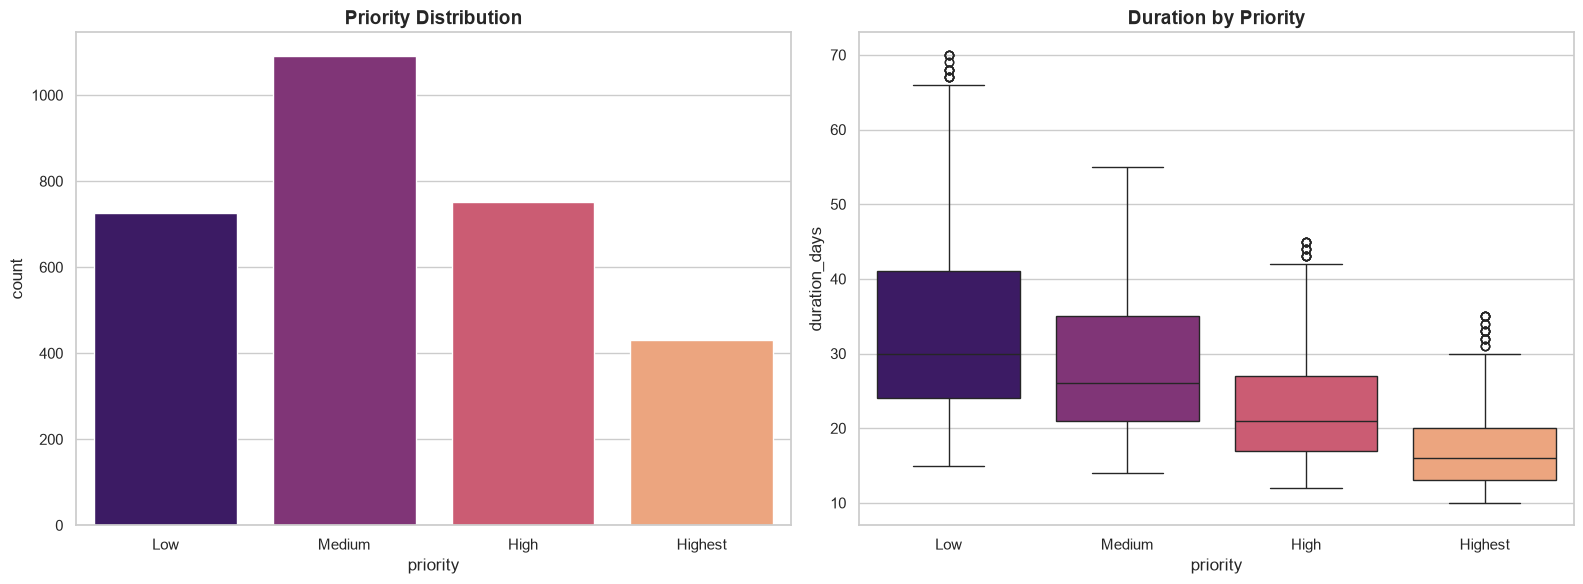

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

priority_order = ['Low', 'Medium', 'High', 'Highest']
sns.countplot(data=df, x='priority', order=priority_order, ax=axes[0], palette='magma')
axes[0].set_title('Priority Distribution', fontsize=14, fontweight='bold')

sns.boxplot(data=df, x='priority', y='duration_days', order=priority_order, ax=axes[1], palette='magma')
axes[1].set_title('Duration by Priority', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/02_priority_distribution.png', bbox_inches='tight')
plt.show()

### 3.3 Duration Analysis

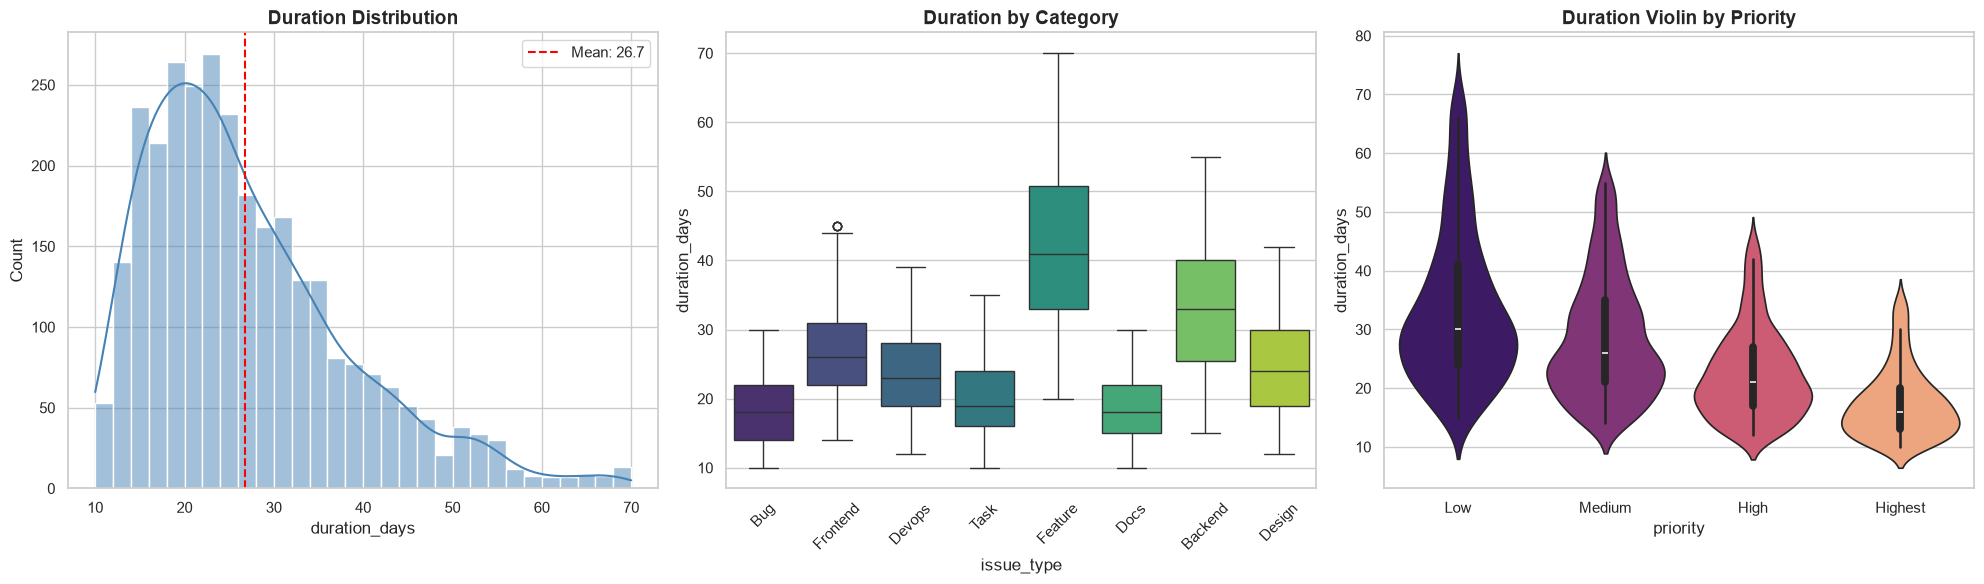

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df['duration_days'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Duration Distribution', fontsize=14, fontweight='bold')
axes[0].axvline(df['duration_days'].mean(), color='red', linestyle='--', label=f"Mean: {df['duration_days'].mean():.1f}")
axes[0].legend()

sns.boxplot(data=df, x='issue_type', y='duration_days', ax=axes[1], palette='viridis')
axes[1].set_title('Duration by Category', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

sns.violinplot(data=df, x='priority', y='duration_days', order=priority_order, ax=axes[2], palette='magma')
axes[2].set_title('Duration Violin by Priority', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/03_duration_analysis.png', bbox_inches='tight')
plt.show()

### 3.4 Correlation Heatmap

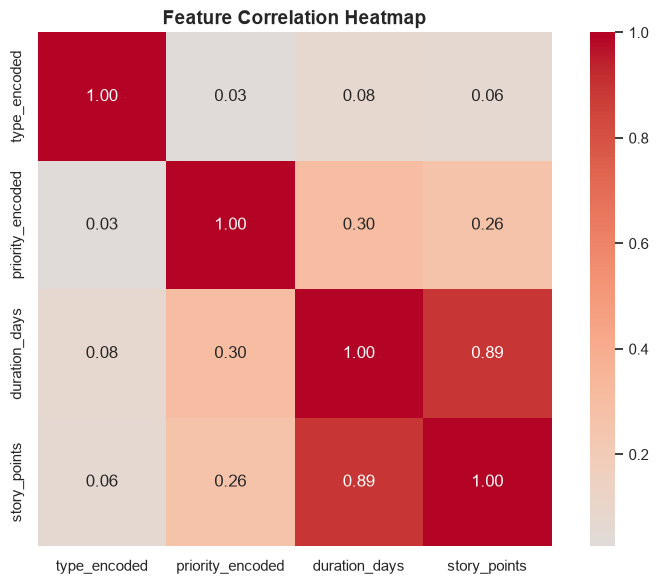

In [8]:
# Encode categoricals for correlation
df_corr = df.copy()
le_type = LabelEncoder()
le_pri = LabelEncoder()
df_corr['type_encoded'] = le_type.fit_transform(df_corr['issue_type'])
df_corr['priority_encoded'] = le_pri.fit_transform(df_corr['priority'])

corr_cols = ['type_encoded', 'priority_encoded', 'duration_days', 'story_points']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 3.5 Cross-tabulation: Category × Priority

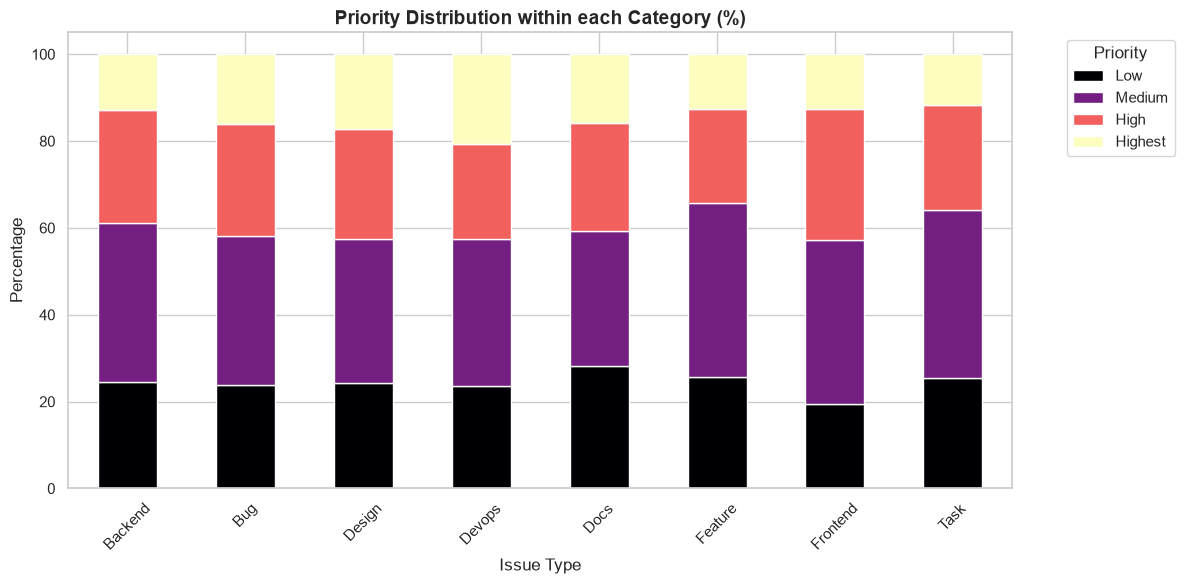

In [9]:
ct = pd.crosstab(df['issue_type'], df['priority'], normalize='index') * 100
ct = ct[priority_order]

fig, ax = plt.subplots(figsize=(12, 6))
ct.plot(kind='bar', stacked=True, ax=ax, colormap='magma')
ax.set_title('Priority Distribution within each Category (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xlabel('Issue Type')
ax.legend(title='Priority', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/05_category_priority_crosstab.png', bbox_inches='tight')
plt.show()

### 3.6 Story Points Analysis

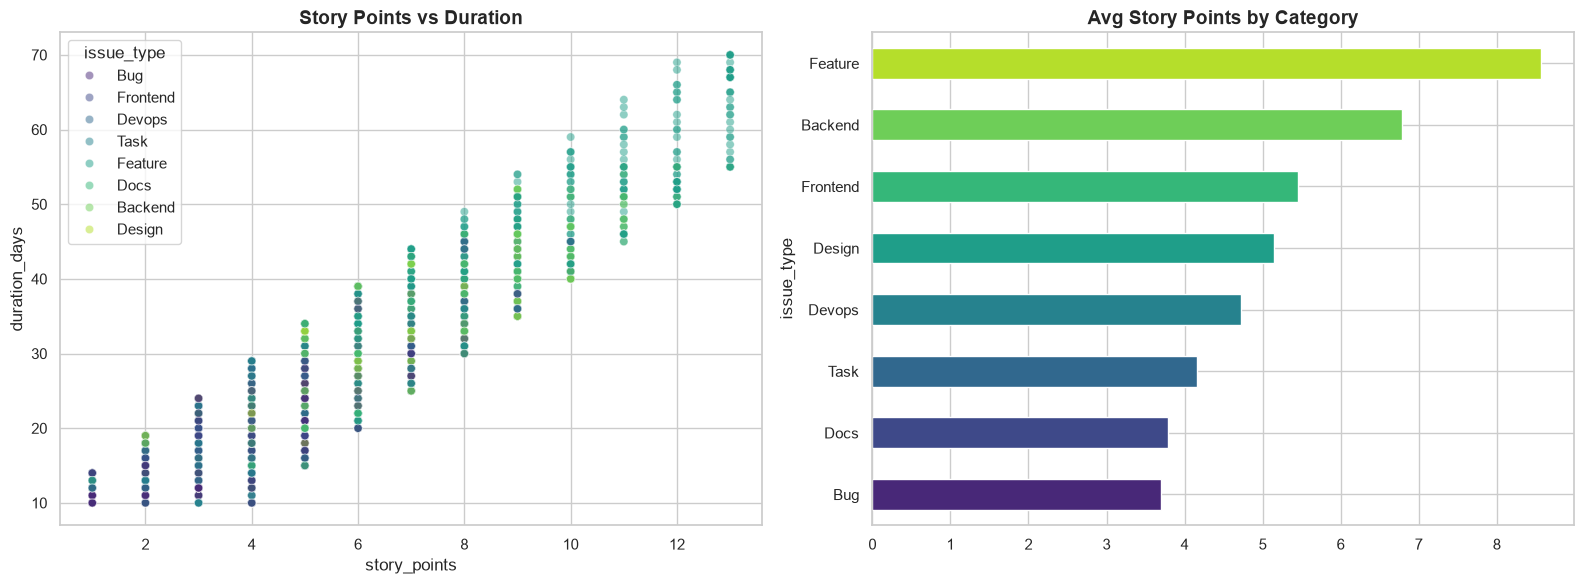

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='story_points', y='duration_days', hue='issue_type', alpha=0.5, ax=axes[0], palette='viridis')
axes[0].set_title('Story Points vs Duration', fontsize=14, fontweight='bold')

avg_sp = df.groupby('issue_type')['story_points'].mean().sort_values()
avg_sp.plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis', 8))
axes[1].set_title('Avg Story Points by Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/06_story_points.png', bbox_inches='tight')
plt.show()

### 3.7 Status Distribution

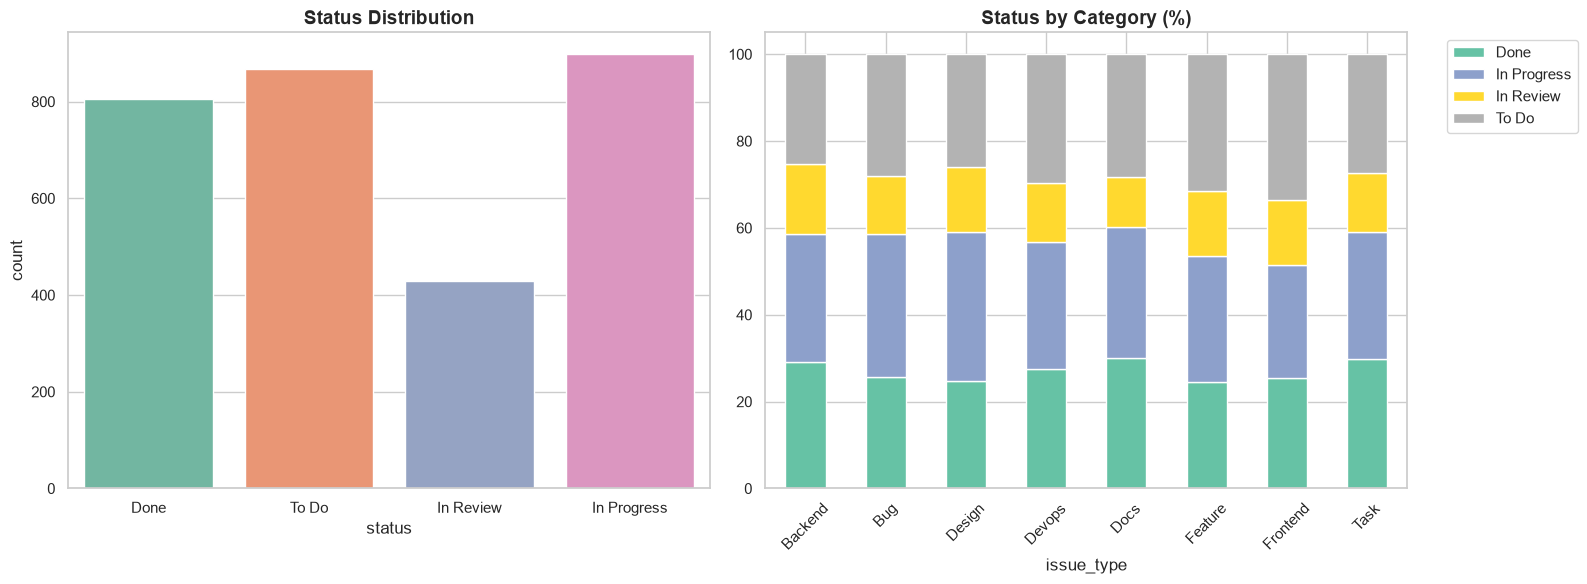

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='status', ax=axes[0], palette='Set2')
axes[0].set_title('Status Distribution', fontsize=14, fontweight='bold')

status_ct = pd.crosstab(df['issue_type'], df['status'], normalize='index') * 100
status_ct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Status by Category (%)', fontsize=14, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('plots/07_status_distribution.png', bbox_inches='tight')
plt.show()

### 3.8 Text Length Analysis

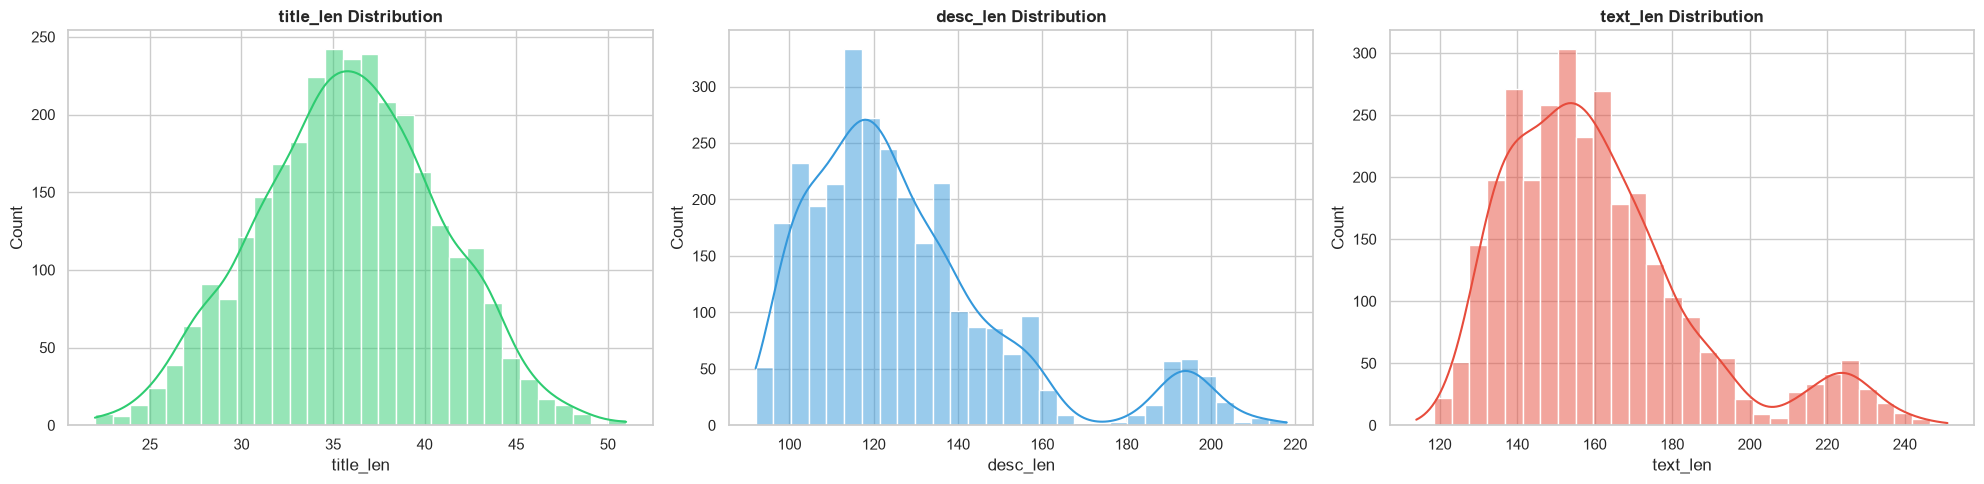

In [12]:
df['title_len'] = df['title'].str.len()
df['desc_len'] = df['description'].str.len()
df['text_len'] = df['text'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, col in enumerate(['title_len', 'desc_len', 'text_len']):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color=['#2ecc71','#3498db','#e74c3c'][i])
    axes[i].set_title(f'{col} Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/08_text_length.png', bbox_inches='tight')
plt.show()

---
## 🤖 4. Model 1: Task Type Classifier

> **Goal**: Classify issue text into 8 categories
>
> **Algorithm**: TF-IDF + Logistic Regression

In [13]:
X_text = df['text']
y_type = df['issue_type']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_text, y_type, test_size=0.2, random_state=42, stratify=y_type)
print(f"Train: {X_train_t.shape[0]}, Test: {X_test_t.shape[0]}")
print(f"Classes: {y_type.nunique()}")

Train: 2400, Test: 600
Classes: 8


In [14]:
# Build pipeline
task_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42))
])

# Cross-validation
cv_scores = cross_val_score(task_pipeline, X_train_t, y_train_t, cv=5, scoring='accuracy')
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Train
task_pipeline.fit(X_train_t, y_train_t)
y_pred_t = task_pipeline.predict(X_test_t)

acc_t = accuracy_score(y_test_t, y_pred_t)
print(f"\nTest Accuracy: {acc_t:.4f}")
print(f"\n{classification_report(y_test_t, y_pred_t)}")

CV Accuracy: 1.0000 ± 0.0000



Test Accuracy: 1.0000

              precision    recall  f1-score   support

     Backend       1.00      1.00      1.00        74
         Bug       1.00      1.00      1.00       109
      Design       1.00      1.00      1.00        50
      Devops       1.00      1.00      1.00        50
        Docs       1.00      1.00      1.00        42
     Feature       1.00      1.00      1.00       108
    Frontend       1.00      1.00      1.00        78
        Task       1.00      1.00      1.00        89

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



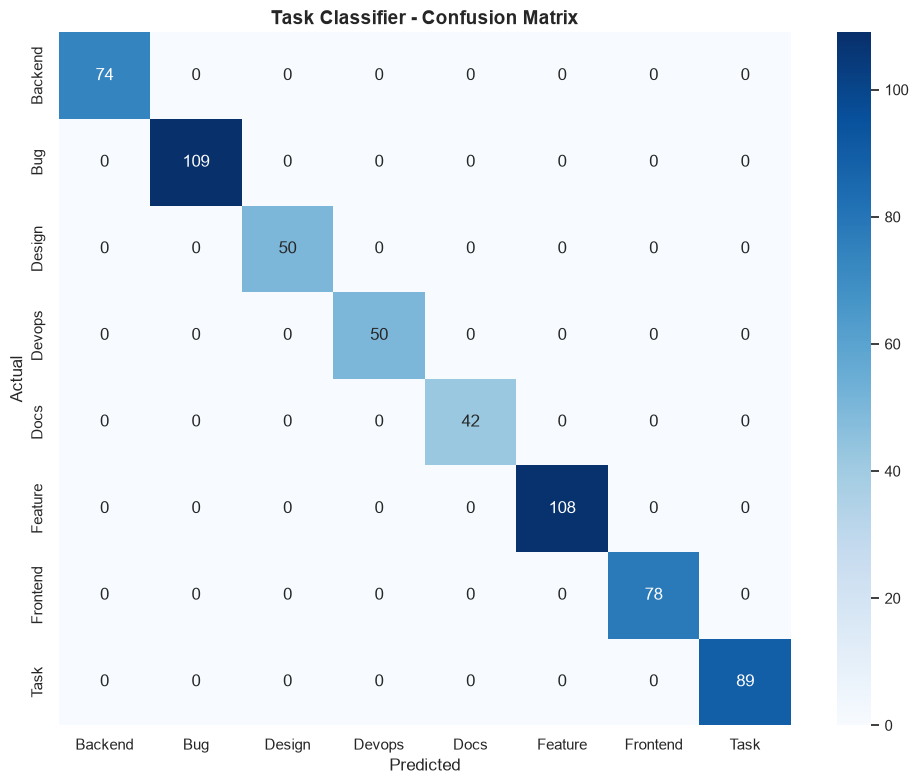

In [15]:
# Confusion Matrix
cm_t = confusion_matrix(y_test_t, y_pred_t, labels=task_pipeline.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues', xticklabels=task_pipeline.classes_, yticklabels=task_pipeline.classes_)
plt.title('Task Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('plots/09_task_classifier_cm.png', bbox_inches='tight')
plt.show()

---
## 🎯 5. Model 2: Priority Classifier

> **Goal**: Predict priority (Low, Medium, High, Highest)
>
> **Algorithm**: TF-IDF + Random Forest Classifier

In [16]:
y_pri = df['priority']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_text, y_pri, test_size=0.2, random_state=42, stratify=y_pri)

priority_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')),
    ('clf', RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42))
])

cv_scores_p = cross_val_score(priority_pipeline, X_train_p, y_train_p, cv=5, scoring='accuracy')
print(f"CV Accuracy: {cv_scores_p.mean():.4f} ± {cv_scores_p.std():.4f}")

priority_pipeline.fit(X_train_p, y_train_p)
y_pred_p = priority_pipeline.predict(X_test_p)

acc_p = accuracy_score(y_test_p, y_pred_p)
print(f"\nTest Accuracy: {acc_p:.4f}")
print(f"\n{classification_report(y_test_p, y_pred_p)}")

CV Accuracy: 0.3521 ± 0.0094



Test Accuracy: 0.3567

              precision    recall  f1-score   support

        High       0.15      0.03      0.05       150
     Highest       0.00      0.00      0.00        86
         Low       0.33      0.03      0.05       146
      Medium       0.37      0.94      0.53       218

    accuracy                           0.36       600
   macro avg       0.21      0.25      0.16       600
weighted avg       0.25      0.36      0.22       600



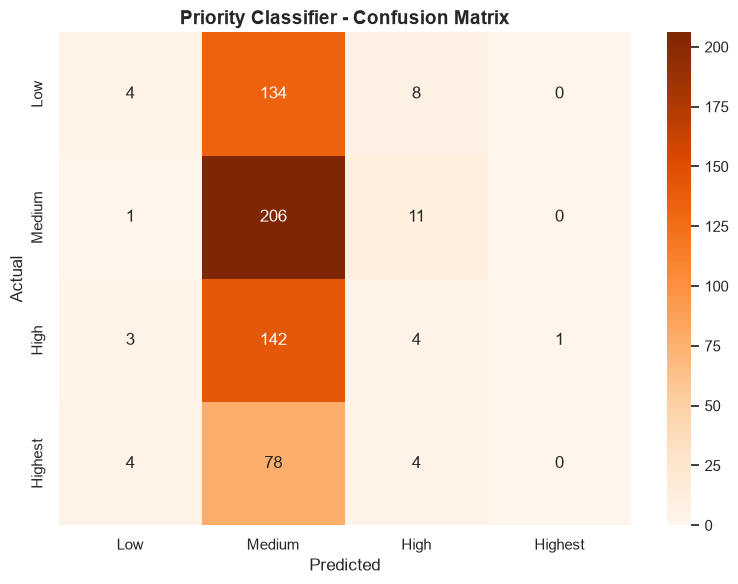

In [17]:
# Confusion Matrix
cm_p = confusion_matrix(y_test_p, y_pred_p, labels=['Low','Medium','High','Highest'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Oranges', xticklabels=['Low','Medium','High','Highest'], yticklabels=['Low','Medium','High','Highest'])
plt.title('Priority Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('plots/10_priority_classifier_cm.png', bbox_inches='tight')
plt.show()

---
## ⏱️ 6. Model 3: Duration Predictor

> **Goal**: Predict task duration in days (integer, minimum 10)
>
> **Algorithm**: TF-IDF text + encoded features → Random Forest Regressor

In [18]:
from scipy.sparse import hstack

# Encode category and priority as features alongside text
le_cat = LabelEncoder()
le_pri_d = LabelEncoder()

df['cat_encoded'] = le_cat.fit_transform(df['issue_type'])
df['pri_encoded'] = le_pri_d.fit_transform(df['priority'])

y_dur = df['duration_days']

X_train_d, X_test_d, y_train_d, y_test_d, idx_train, idx_test = train_test_split(
    X_text, y_dur, df.index, test_size=0.2, random_state=42
)

# TF-IDF on text
tfidf_dur = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = tfidf_dur.fit_transform(X_train_d)
X_test_tfidf = tfidf_dur.transform(X_test_d)

# Add encoded features
import scipy.sparse as sp
extra_train = sp.csr_matrix(df.loc[idx_train, ['cat_encoded', 'pri_encoded']].values)
extra_test = sp.csr_matrix(df.loc[idx_test, ['cat_encoded', 'pri_encoded']].values)

X_train_combined = hstack([X_train_tfidf, extra_train])
X_test_combined = hstack([X_test_tfidf, extra_test])

print(f"Combined feature shape: {X_train_combined.shape}")

Combined feature shape: (2400, 3002)


In [19]:
# Train Random Forest Regressor
dur_model = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_split=10, min_samples_leaf=5, random_state=42
)
dur_model.fit(X_train_combined, y_train_d)

y_pred_d = dur_model.predict(X_test_combined)

# Round and enforce minimum 10 days
y_pred_d = np.maximum(np.round(y_pred_d).astype(int), 10)

mae = mean_absolute_error(y_test_d, y_pred_d)
rmse = np.sqrt(mean_squared_error(y_test_d, y_pred_d))
r2 = r2_score(y_test_d, y_pred_d)

print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")
print(f"R²:   {r2:.4f}")
print(f"Min predicted: {y_pred_d.min()}, Max predicted: {y_pred_d.max()}")

MAE:  4.39 days
RMSE: 5.82 days
R²:   0.7527
Min predicted: 12, Max predicted: 59


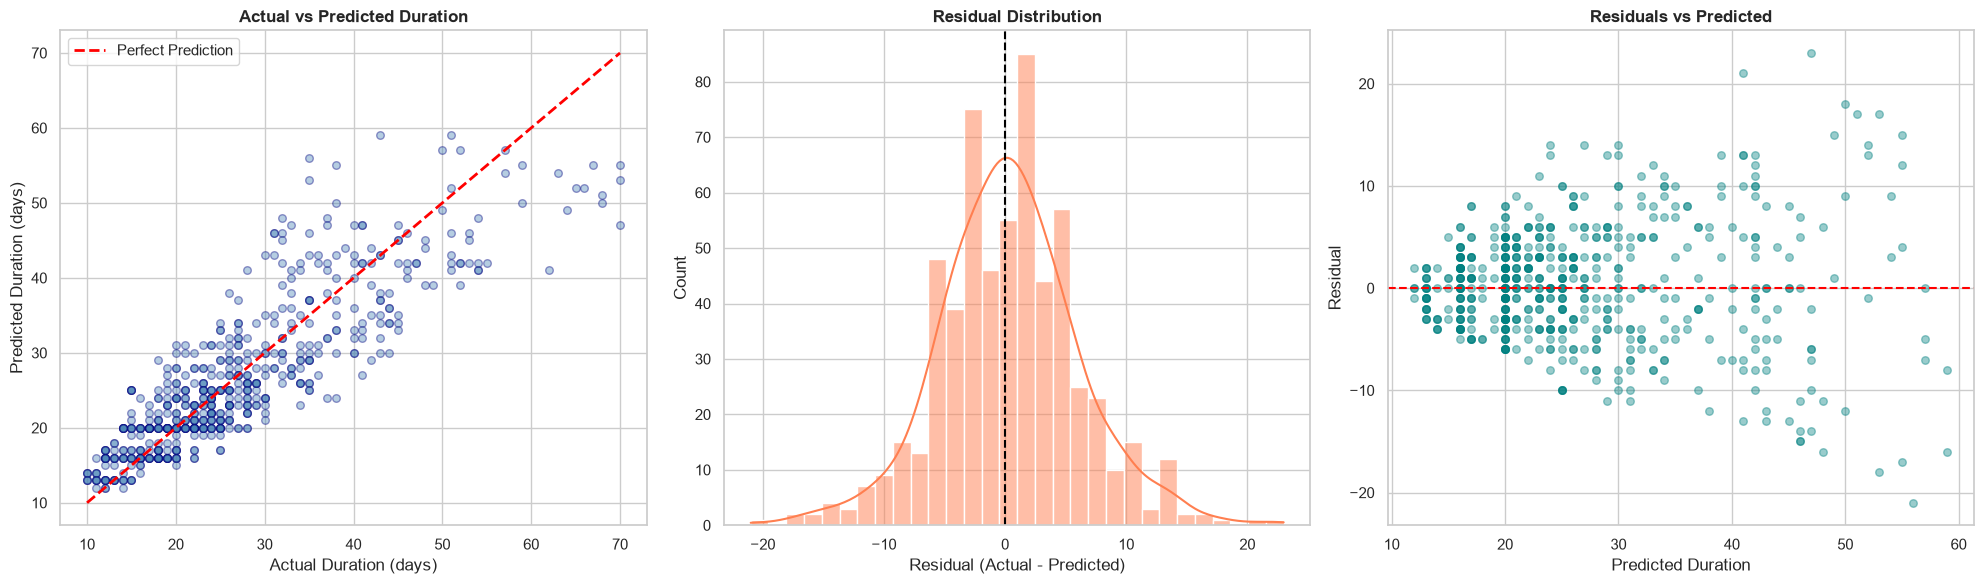

In [20]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(y_test_d, y_pred_d, alpha=0.4, c='steelblue', edgecolors='navy', s=30)
axes[0].plot([10, 70], [10, 70], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Duration (days)')
axes[0].set_ylabel('Predicted Duration (days)')
axes[0].set_title('Actual vs Predicted Duration', fontweight='bold')
axes[0].legend()

residuals = y_test_d.values - y_pred_d
sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')

axes[2].scatter(y_pred_d, residuals, alpha=0.4, c='teal', s=30)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')
axes[2].set_xlabel('Predicted Duration')
axes[2].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('plots/11_duration_predictor.png', bbox_inches='tight')
plt.show()

---
## 💾 7. Save Models to Pickle Files

In [21]:
os.makedirs('models', exist_ok=True)

# 1. Task Classifier Pipeline
joblib.dump(task_pipeline, 'models/task_classifier.pkl')
print("✅ Saved: models/task_classifier.pkl")

# 2. Priority Classifier Pipeline
joblib.dump(priority_pipeline, 'models/priority_classifier.pkl')
print("✅ Saved: models/priority_classifier.pkl")

# 3. Duration Predictor (save model + vectorizer + encoders separately)
joblib.dump(dur_model, 'models/duration_predictor.pkl')
joblib.dump(tfidf_dur, 'models/duration_tfidf.pkl')
joblib.dump(le_cat, 'models/label_encoder_category.pkl')
joblib.dump(le_pri_d, 'models/label_encoder_priority.pkl')
print("✅ Saved: duration predictor artifacts")

print("\n🎉 All models saved successfully!")

✅ Saved: models/task_classifier.pkl


✅ Saved: models/priority_classifier.pkl
✅ Saved: duration predictor artifacts

🎉 All models saved successfully!


---
## 📋 8. Model Performance Summary

In [22]:
summary = pd.DataFrame({
    'Model': ['Task Classifier', 'Priority Classifier', 'Duration Predictor'],
    'Algorithm': ['TF-IDF + Logistic Regression', 'TF-IDF + Random Forest Classifier', 'TF-IDF + Random Forest Regressor'],
    'Metric': ['Accuracy', 'Accuracy', 'R² / MAE'],
    'Score': [f"{acc_t:.4f}", f"{acc_p:.4f}", f"{r2:.4f} / {mae:.2f}d"]
})
print(summary.to_string(index=False))

              Model                         Algorithm   Metric          Score
    Task Classifier      TF-IDF + Logistic Regression Accuracy         1.0000
Priority Classifier TF-IDF + Random Forest Classifier Accuracy         0.3567
 Duration Predictor  TF-IDF + Random Forest Regressor R² / MAE 0.7527 / 4.39d


---
## 🧪 9. Quick Inference Test

In [23]:
test_texts = [
    "Fix login button not working on mobile Safari browser",
    "Implement OAuth2 single sign-on for enterprise users",
    "Set up Kubernetes cluster with auto-scaling on AWS",
    "Design new dashboard layout with dark mode support",
    "Write API documentation for the payment module endpoints",
    "Build drag-and-drop file upload component with progress bar",
    "Create REST API endpoint for user profile management",
    "Update project configuration and clean up unused code"
]

print("=" * 80)
print(f"{'Text':<55} {'Type':<10} {'Priority':<10} {'Days'}")
print("=" * 80)

for text in test_texts:
    cat = task_pipeline.predict([text.lower()])[0]
    pri = priority_pipeline.predict([text.lower()])[0]
    
    # Duration prediction
    text_tfidf = tfidf_dur.transform([text.lower()])
    cat_enc = le_cat.transform([cat])[0]
    pri_enc = le_pri_d.transform([pri])[0]
    extra = sp.csr_matrix([[cat_enc, pri_enc]])
    combined = hstack([text_tfidf, extra])
    dur = max(10, int(round(dur_model.predict(combined)[0])))
    
    print(f"{text[:53]:<55} {cat:<10} {pri:<10} {dur}")

print("=" * 80)

Text                                                    Type       Priority   Days
Fix login button not working on mobile Safari browser   Bug        Medium     20
Implement OAuth2 single sign-on for enterprise users    Bug        Medium     33
Set up Kubernetes cluster with auto-scaling on AWS      Devops     Medium     22
Design new dashboard layout with dark mode support      Design     Medium     43
Write API documentation for the payment module endpoi   Docs       Medium     20


Build drag-and-drop file upload component with progre   Frontend   Medium     31


Create REST API endpoint for user profile management    Backend    Medium     30
Update project configuration and clean up unused code   Task       Medium     20
